In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [2]:
tab2 = Table.read("C:/Users/Ruben/Desktop/All_candidates.vot")

In [3]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m


dist_pc2 = r_from_plx(np.array(tab2["parallax"])) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"])
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5
teff2 = np.array(tab2["teff_gspphot"]) # in K
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag

print('Anzahl Sterne gesamt: ', len(tab2))
print('Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude: ', len(tab2[np.isnan(absolute_magnitude2)]), ' vernachlässigbar')
absmag = (absolute_magnitude2 >= 5) & (absolute_magnitude2 <= 8)
print('Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag: ', len(tab2[absmag]))
print('davon ohne Teff: ', len(tab2[absmag][np.isnan(teff2[absmag])]))
print('davon mit richtiger Teff: ', len(tab2[absmag][(teff2[absmag]>=4000)&(teff2[absmag]<=5000)]), ' ungefähr alle aus der anderen Query')
print('davon ohne z: ', len(tab2[absmag][np.isnan(z_pc2[absmag])]))
print('davon ohne bp_rp: ', len(tab2[absmag][np.isnan(bp_rp2[absmag])]), ' vernachlässigbar')
print('davon ohne bp_g: ', len(tab2[absmag][np.isnan(bp_g2[absmag])]), ' vernachlässigbar')
print('davon ohne g_rp: ', len(tab2[absmag][np.isnan(g_rp2[absmag])]), ' vernachlässigbar')
print('davon im kleinen Zylinder: ', len(tab2[absmag&(r_pc2<100)]))

Anzahl Sterne gesamt:  9801080
Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude:  19848  vernachlässigbar
Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag:  968550
davon ohne Teff:  155387
davon mit richtiger Teff:  545857  ungefähr alle aus der anderen Query
davon ohne z:  0
davon ohne bp_rp:  8153  vernachlässigbar
davon ohne bp_g:  8107  vernachlässigbar
davon ohne g_rp:  8106  vernachlässigbar
davon im kleinen Zylinder:  241863


In [4]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# scatter = ax[0].scatter(g_rp2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram')
# ax[0].invert_yaxis()
# ax[0].set_xlim(-0.5, 2.5)
# ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(30)
# plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# scatter = ax[0].scatter(bp_g2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram')
# ax[0].set_xlabel(rf'$G_{{BP}}-G$ [mag]')
# ax[0].invert_yaxis()
# ax[0].set_xlim(-0.5, 2.5)
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(30)
# plt.show()

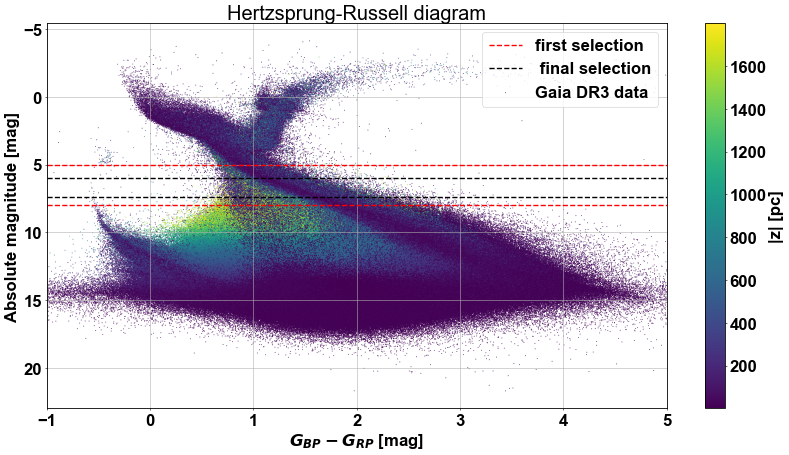

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(bp_rp2[np.where(abs(z_pc2)<=1800)], absolute_magnitude2[np.where(abs(z_pc2)<=1800)], c=np.abs(z_pc2)[np.where(abs(z_pc2)<=1800)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('../Plots/hr_colour.png')
fig.set_dpi(50)
plt.show()

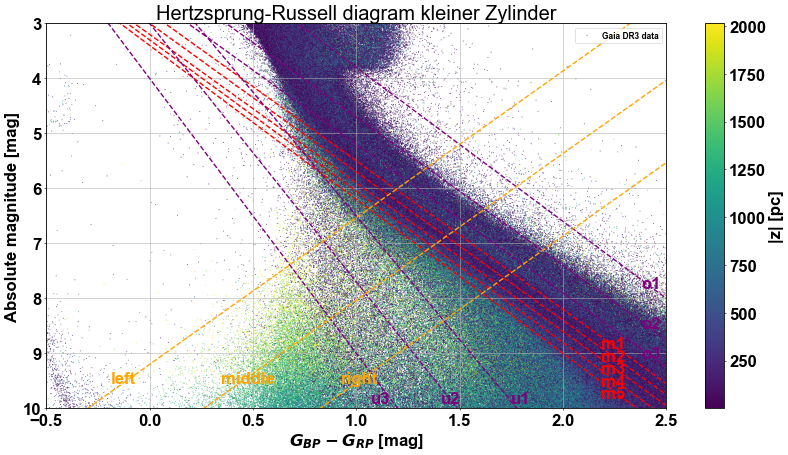

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.5, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(bp_rp2[(r_pc2<200)], absolute_magnitude2[(r_pc2<200)], c=np.abs(z_pc2)[(r_pc2<200)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].axvline(x=1.0, color='g', linestyle='--', linewidth=2)
# ax[0].axvline(x=1.2, color='g', linestyle='--', linewidth=2)
# ax[0].axvline(x=1.4, color='g', linestyle='--', linewidth=2)
# ax[0].axvline(x=1.6, color='g', linestyle='--', linewidth=2)
# ax[0].axvline(x=1.8, color='g', linestyle='--', linewidth=2)
# ax[0].axvline(x=2.0, color='g', linestyle='--', linewidth=2)

x = np.array([-1,5])
# ax[0].plot(x, 1.3 * (-1/3) * x + 8.4, color='b', linestyle='--', linewidth=2)
# # ax[0].plot(x, 1.2 * (-1/3) * x + 7.6, color='b', linestyle='--', linewidth=2)
# ax[0].plot(x, 1.1 * (-1/3) * x + 6.9, color='b', linestyle='--', linewidth=2)
# # ax[0].plot(x, 0.9 * (-1/3) * x + 6.1, color='b', linestyle='--', linewidth=2)
# ax[0].plot(x, 0.7 * (-1/3) * x + 5.3, color='b', linestyle='--', linewidth=2)

ax[0].plot(x, 2.8*x+1.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+2.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+2.5, color='purple', linestyle='--', linewidth=2)

ax[0].plot(x, 2.7*x+2.8, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+3.0, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+3.2, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.75*x+3.3, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.8*x+3.4, color='red', linestyle='--', linewidth=2)

ax[0].plot(x, 4.5*x+2.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 4.7*x+3.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 5.0*x+4.0, color='purple', linestyle='--', linewidth=2)


ax[0].plot(x, 8 * (-1/3) * x + 9.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 12.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 10.7, color='orange', linestyle='--', linewidth=2)



ax[0].grid()
ax[0].legend(loc='upper right', fontsize='12')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram kleiner Zylinder')
ax[0].invert_yaxis()
# ax[0].set_xlim(-0, 3)
# ax[0].set_ylim(8, 5)
ax[0].set_xlim(-0.5, 2.5)
ax[0].set_ylim(10, 3)
plt.figtext(0.45, 0.12, 'u3', color='purple')
plt.figtext(0.52, 0.12, 'u2', color='purple')
plt.figtext(0.59, 0.12, 'u1', color='purple')

plt.figtext(0.19, 0.16, 'left', color='orange')
plt.figtext(0.3, 0.16, 'middle', color='orange')
plt.figtext(0.42, 0.16, 'right', color='orange')

plt.figtext(0.72, 0.35, 'o1', color='purple')
plt.figtext(0.72, 0.27, 'o2', color='purple')
plt.figtext(0.72, 0.21, 'o3', color='purple')

plt.figtext(0.68, 0.23, 'm1', color='red')
plt.figtext(0.68, 0.205, 'm2', color='red')
plt.figtext(0.68, 0.18, 'm3', color='red')
plt.figtext(0.68, 0.155, 'm4', color='red')
plt.figtext(0.68, 0.13, 'm5', color='red')

colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('../Plots/hr_colour_zoom.png')
fig.set_dpi(50)
plt.show()

In [7]:
aa = (absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.4)
rr = r_pc2<200
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# for inter in [[1.0,1.2], [1.2,1.4], [1.4,1.6], [1.6,1.8], [1.8,2.0]]:
#     br = (bp_rp2[aa&rr]>=inter[0]) & (bp_rp2[aa&rr]<=inter[1])
#     print('Anzahl Sterne im Bereich ', inter[0], ' < $G_{BP}-G_{RP}$ < ', inter[1], ': ', len(tab2[aa&rr][br]))
#     n, bins = np.histogram(z_pc2[aa&rr][br], bins=40)
#     ax.plot((bins[:-1]+bins[1:])/2, n/n[20], label=str(inter[0])+' < $G_{BP}-G_{RP}$ < '+str(inter[1]))

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# fig.set_dpi(50)
# plt.show()
# print('Range von 1.2 bis 1.6 sieht okay aus')
# print('Insgesamt Unfug!!')

In [8]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# # ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# # ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# # ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# # ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[0].plot(x, 2.8*x+1.0, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 2.7*x+2.0, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 2.7*x+2.5, color='purple', linestyle='--', linewidth=2)

# ax[0].plot(x, 2.7*x+2.8, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 2.7*x+3.0, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 2.7*x+3.2, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 2.8*x+3.4, color='purple', linestyle='--', linewidth=2)

# ax[0].plot(x, 4.5*x+2.0, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 4.7*x+3.0, color='purple', linestyle='--', linewidth=2)
# ax[0].plot(x, 5.0*x+4.0, color='purple', linestyle='--', linewidth=2)


# ax[0].plot(x, 8 * (-1/3) * x + 9.2, color='orange', linestyle='--', linewidth=2)
# ax[0].plot(x, 8 * (-1/3) * x + 12.2, color='orange', linestyle='--', linewidth=2)
# ax[0].plot(x, 8 * (-1/3) * x + 10.7, color='orange', linestyle='--', linewidth=2)

# scatter = ax[0].scatter(bp_rp2[(teff2<5300)&(teff2>3900)], absolute_magnitude2[(teff2<5300)&(teff2>3900)], c=teff2[(teff2<5300)&(teff2>3900)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram within relevant temperature range')
# ax[0].invert_yaxis()
# ax[0].set_xlim(-1, 5)
# ax[0].set_ylim(20,-5)
# colorbar = fig.colorbar(scatter, ax=ax, label=rf'$T_{{eff}}$ [K]')
# fig.set_dpi(50)
# plt.show()

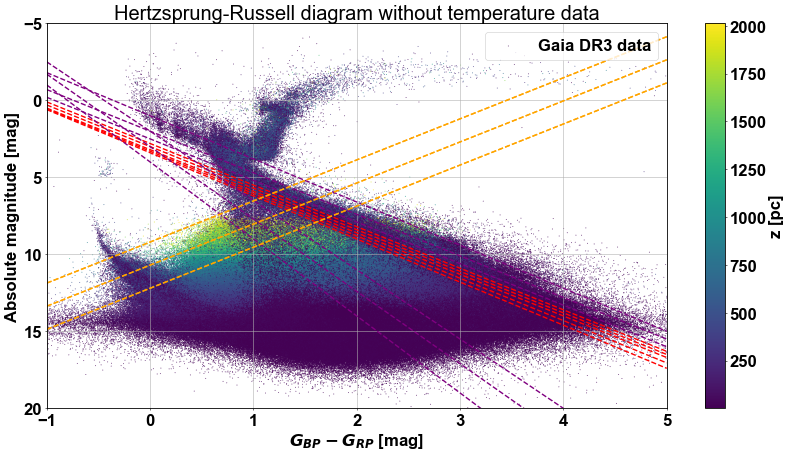

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

ax[0].plot(x, 2.8*x+1.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+2.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+2.5, color='purple', linestyle='--', linewidth=2)

ax[0].plot(x, 2.7*x+2.8, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+3.0, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.7*x+3.2, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.75*x+3.3, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 2.8*x+3.4, color='red', linestyle='--', linewidth=2)

ax[0].plot(x, 4.5*x+2.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 4.7*x+3.0, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 5.0*x+4.0, color='purple', linestyle='--', linewidth=2)


ax[0].plot(x, 8 * (-1/3) * x + 9.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 12.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 10.7, color='orange', linestyle='--', linewidth=2)



ax[0].plot(x, 8 * (-1/3) * x + 9.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 12.2, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 10.7, color='orange', linestyle='--', linewidth=2)

scatter = ax[0].scatter(bp_rp2[np.isnan(teff2)], absolute_magnitude2[np.isnan(teff2)], c=abs(z_pc2[np.isnan(teff2)]), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram without temperature data')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
ax[0].set_ylim(20,-5)
colorbar = fig.colorbar(scatter, ax=ax, label=rf'z [pc]')
fig.set_dpi(50)
plt.show()

In [10]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax = [ax]
# ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
# ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
# ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
# ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)

# scatter = ax[0].scatter(teff2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

# ax[0].grid()
# ax[0].legend(loc='upper right')

# ax[0].set_xlabel('Effective temperature [K]')
# ax[0].set_ylabel('Absolute magnitude [mag]')
# ax[0].set_title('Hertzsprung-Russell diagram with temperature data')
# ax[0].invert_yaxis()
# ax[0].invert_xaxis()
# ax[0].set_xlim(6000, 2500)
# colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
# fig.set_dpi(50)
# plt.show()

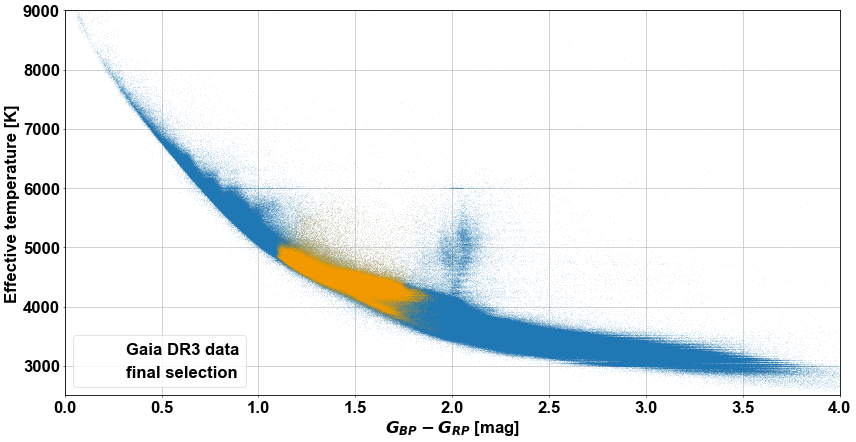

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

o1 = 2.8*bp_rp2+1.0
m4 = 2.75*bp_rp2+3.3

left = (8 * (-1/3) * bp_rp2 + 9.2)
right = (8 * (-1/3) * bp_rp2 + 12.2)

ax.plot(bp_rp2, teff2, '.', markersize=1, label='Gaia DR3 data', alpha=0.1)
# ax.plot(bp_rp2[aa&rr], teff2[aa&rr], '.', markersize=1, label='absolut magnitude cut', alpha=0.1)
ax.plot(bp_rp2[rr&(absolute_magnitude2>=left)&(absolute_magnitude2<=right)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)], teff2[rr&(absolute_magnitude2>=left)&(absolute_magnitude2<=right)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)], '.', markersize=1, label='final selection', color='orange', alpha=0.1)
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# plt.axvline(x=1.2, color='r', linestyle='--', linewidth=2, label='1.2')
# plt.axvline(x=1.8, color='r', linestyle='--', linewidth=2, label='1.8')
# plt.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='1.0')
# plt.axvline(x=2.0, color='r', linestyle='--', linewidth=2, label='2.0')
ax.set_xlabel(rf'$G_{{BP}}-G_{{RP}}$ [mag]')
ax.set_ylabel('Effective temperature [K]')
ax.set_ylim(2500, 9000)
ax.set_xlim(0, 4)
plt.grid(which='both')
plt.legend()
plt.savefig('../Plots/teff_bp_rp.png')
fig.set_dpi(50)
plt.show()

In [12]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot(g_rp2, teff2, '.', markersize=1, label='Gaia DR3 data')
# ax.plot(g_rp2[absmagcut&(np.abs(r_pc2)<100)], teff2[absmagcut&(np.abs(r_pc2)<100)], '.', markersize=1, label='selected stars')
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# ax.set_xlabel(rf'$G-G_{{RP}}$ [mag]')
# ax.set_ylabel('Effective temperature [K]')
# ax.set_ylim(2500, 9000)
# ax.set_xlim(0, 1.5)
# plt.grid(which='both')
# fig.set_dpi(30)
# plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot(bp_g2, teff2, '.', markersize=1, label='Gaia DR3 data')
# ax.plot(bp_g2[absmagcut&(np.abs(r_pc2)<100)], teff2[absmagcut&(np.abs(r_pc2)<100)], '.', markersize=1, label='selected stars')
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# ax.set_xlabel(rf'$G_{{BP}}-G$ [mag]')
# ax.set_ylabel('Effective temperature [K]')
# ax.set_ylim(2500, 9000)
# ax.set_xlim(0, 2.5)
# plt.grid(which='both')
# fig.set_dpi(30)
# plt.show()

In [13]:
a = (absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.5)
a1 = (absolute_magnitude2>=5)&(absolute_magnitude2<=6.2)
a2 = (absolute_magnitude2>=6.2)&(absolute_magnitude2<=6.4)
a3 = (absolute_magnitude2>=6.4)&(absolute_magnitude2<=6.6)
a4 = (absolute_magnitude2>=6.6)&(absolute_magnitude2<=7.0)
a5 = (absolute_magnitude2>=7.0)&(absolute_magnitude2<=7.2)
a6 = (absolute_magnitude2>=7.2)&(absolute_magnitude2<=7.4)
a7 = (absolute_magnitude2>=7.4)&(absolute_magnitude2<=8)

r = r_pc2<200
t = (teff2>=4000) & (teff2<=5000)

br = (bp_rp2>=1.2) & (bp_rp2<=1.8)
br2 = (bp_rp2>=1.0) & (bp_rp2<=2.0)
br3 = (bp_rp2>=1.4) & (bp_rp2<=1.6)

abr = (absolute_magnitude2>=3*bp_rp2+0.5)&(absolute_magnitude2<=3*bp_rp2+4.5)
abr1 = (absolute_magnitude2>=3*bp_rp2+0.5)&(absolute_magnitude2<=3*bp_rp2+2.5)
abr2 = (absolute_magnitude2>=3*bp_rp2+2.5)&(absolute_magnitude2<=3*bp_rp2+4.5)

o1 = 2.8*bp_rp2+1.0
o2 = 2.7*bp_rp2+2.0
o3 = 2.7*bp_rp2+2.5

m1 = 2.7*bp_rp2+2.8
m2 = 2.7*bp_rp2+3.0
m3 = 2.7*bp_rp2+3.2
m4 = 2.75*bp_rp2+3.3
m5 = 2.8*bp_rp2+3.4 #ehemals u1

u1 = 4.5*bp_rp2+2.0 #ehemals u2
u2 = 4.7*bp_rp2+3.0
u3 = 5.0*bp_rp2+4.0

left = (8 * (-1/3) * bp_rp2 + 9.2)
right = (8 * (-1/3) * bp_rp2 + 12.2)
middle = (8 * (-1/3) * bp_rp2 + 10.7)


bra = (absolute_magnitude2>=(-8/3)*bp_rp2+9.2)&(absolute_magnitude2<=(-8/3)*bp_rp2+12.2)
bra1 = (absolute_magnitude2>=(-8/3)*bp_rp2+9.2)&(absolute_magnitude2<=(-8/3)*bp_rp2+10.7)
bra2 = (absolute_magnitude2>=(-8/3)*bp_rp2+10.7)&(absolute_magnitude2<=(-8/3)*bp_rp2+12.2)

''' Temperatur vs Farbe'''
n1, bins1 = np.histogram(z_pc2[r&a&br2], bins=40)
n2, bins2 = np.histogram(z_pc2[r&a&br2][~np.isnan(teff2[r&a&br2])], bins=40)
n3, bins3 = np.histogram(z_pc2[r&a&br2][np.isnan(teff2[r&a&br2])], bins=40)
n4, bins4 = np.histogram(z_pc2[r&a&br2&t], bins=40)
n5, bins5 = np.histogram(z_pc2[r&a&t], bins=40,)

''' kleines Farb-Interval absolute Magnituden '''
n6, bins6 = np.histogram(z_pc2[r&a1&br], bins=40)
n7, bins7 = np.histogram(z_pc2[r&a2&br], bins=40)
n8, bins8 = np.histogram(z_pc2[r&a3&br], bins=40)
n9, bins9 = np.histogram(z_pc2[r&a4&br], bins=40)
n10, bins10 = np.histogram(z_pc2[r&a5&br], bins=40)
n11, bins11 = np.histogram(z_pc2[r&a6&br], bins=40)
n12, bins12 = np.histogram(z_pc2[r&a7&br], bins=40)
print(np.sum(n6), np.sum(n7), np.sum(n8), np.sum(n9), np.sum(n10), np.sum(n11), np.sum(n12))

''' großes Farb-Interval absolute Magnituden '''
n13, bins13 = np.histogram(z_pc2[r&a1&br2], bins=40)
n14, bins14 = np.histogram(z_pc2[r&a2&br2], bins=40)
n15, bins15 = np.histogram(z_pc2[r&a3&br2], bins=40)
n16, bins16 = np.histogram(z_pc2[r&a4&br2], bins=40)
n17, bins17 = np.histogram(z_pc2[r&a5&br2], bins=40)
n18, bins18 = np.histogram(z_pc2[r&a6&br2], bins=40)
n19, bins19 = np.histogram(z_pc2[r&a7&br2], bins=40)
print(np.sum(n13), np.sum(n14), np.sum(n15), np.sum(n16), np.sum(n17), np.sum(n18), np.sum(n19))

''' Farbinterval '''
n20, bins20 = np.histogram(z_pc2[r&a&br], bins=40)
n21, bins21 = np.histogram(z_pc2[r&a&br2], bins=40)
n22, bins22 = np.histogram(z_pc2[r&a&br3], bins=40)

''' Farbabhängige Magnituden-Cuts '''
n26, bins26 = np.histogram(z_pc2[r&bra&abr], bins=40)
n27, bins27 = np.histogram(z_pc2[r&bra&abr1], bins=40)
n28, bins28 = np.histogram(z_pc2[r&bra&abr2], bins=40)
n29, bins29 = np.histogram(z_pc2[r&bra1&abr], bins=40)
n30, bins30 = np.histogram(z_pc2[r&bra2&abr], bins=40)

''' Subsamples absolute Magnitude '''
n31, bins31 = np.histogram(z_pc2[r&bra&abr&(absolute_magnitude2>5)&(absolute_magnitude2<6.7)], bins=40)
n32, bins32 = np.histogram(z_pc2[r&bra&abr&(absolute_magnitude2>6.7)&(absolute_magnitude2<8)], bins=40)


''' Spezielle Cuts '''
n33, bins33 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n34, bins34 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n35, bins35 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n37, bins37 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n38, bins38 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n39, bins39 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n41, bins41 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n42, bins42 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n43, bins43 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n45, bins45 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n46, bins46 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n47, bins47 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n48, bins48 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n49, bins49 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n50, bins50 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n51, bins51 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n52, bins52 = np.histogram(z_pc2[r&(absolute_magnitude2>=u1)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n53, bins53 = np.histogram(z_pc2[r&(absolute_magnitude2>=m5)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n54, bins54 = np.histogram(z_pc2[r&(absolute_magnitude2>=m4)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n55, bins55 = np.histogram(z_pc2[r&(absolute_magnitude2>=m3)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)



26296 33778 52591 121878 62877 62918 149252
196614 60687 61545 126745 65812 67830 214280


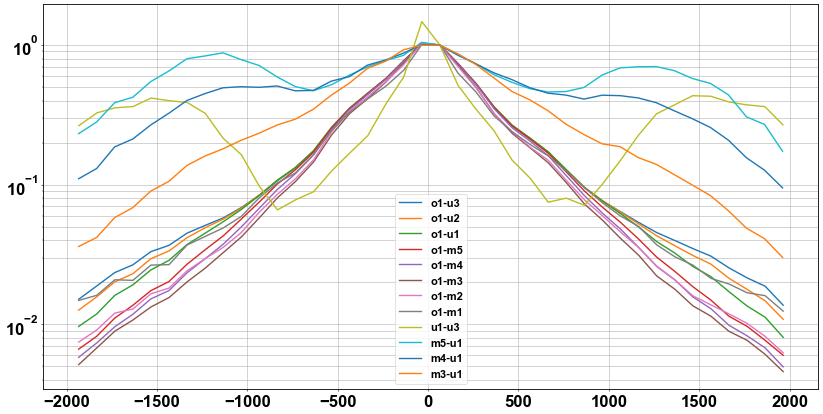

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins35[:-1]+bins35[1:])/2, n35/n35[20], label='o1-u3')
ax.plot((bins34[:-1]+bins34[1:])/2, n34/n34[20], label='o1-u2')
ax.plot((bins33[:-1]+bins33[1:])/2, n33/n33[20], label='o1-u1')

# ax.plot((bins39[:-1]+bins39[1:])/2, n39/n39[20], label='o2-u3')
# ax.plot((bins38[:-1]+bins38[1:])/2, n38/n38[20], label='o2-u2')
# ax.plot((bins37[:-1]+bins37[1:])/2, n37/n37[20], label='o2-u1')

# ax.plot((bins43[:-1]+bins43[1:])/2, n43/n43[20], label='o1-u3')
# ax.plot((bins42[:-1]+bins42[1:])/2, n42/n42[20], label='o1-u2')
# ax.plot((bins41[:-1]+bins41[1:])/2, n41/n41[20], label='o1-u1')

ax.plot((bins49[:-1]+bins49[1:])/2, n49/n49[20], label='o1-m5')
ax.plot((bins48[:-1]+bins48[1:])/2, n48/n48[20], label='o1-m4')
ax.plot((bins47[:-1]+bins47[1:])/2, n47/n47[20], label='o1-m3')
ax.plot((bins46[:-1]+bins46[1:])/2, n46/n46[20], label='o1-m2')
ax.plot((bins45[:-1]+bins45[1:])/2, n45/n45[20], label='o1-m1')

ax.plot((bins52[:-1]+bins52[1:])/2, n52/n52[20], label='u1-u3')
ax.plot((bins53[:-1]+bins53[1:])/2, n53/n53[20], label='m5-u1')
ax.plot((bins54[:-1]+bins54[1:])/2, n54/n54[20], label='m4-u1')
ax.plot((bins55[:-1]+bins55[1:])/2, n55/n55[20], label='m3-u1')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('../Plots/selections.png')
fig.set_dpi(50)
plt.show()

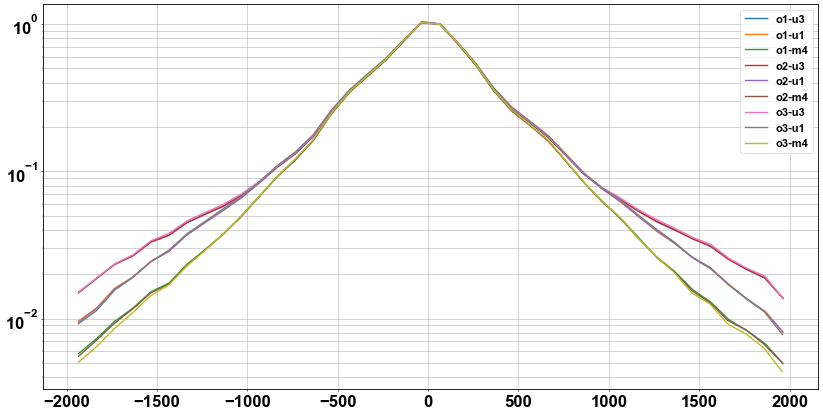

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins35[:-1]+bins35[1:])/2, n35/n35[20], label='o1-u3')
ax.plot((bins33[:-1]+bins33[1:])/2, n33/n33[20], label='o1-u1')
ax.plot((bins48[:-1]+bins48[1:])/2, n48/n48[20], label='o1-m4')
ax.plot((bins39[:-1]+bins39[1:])/2, n39/n39[20], label='o2-u3')
ax.plot((bins37[:-1]+bins37[1:])/2, n37/n37[20], label='o2-u1')
ax.plot((bins50[:-1]+bins50[1:])/2, n50/n50[20], label='o2-m4')
ax.plot((bins43[:-1]+bins43[1:])/2, n43/n43[20], label='o3-u3')
ax.plot((bins41[:-1]+bins41[1:])/2, n41/n41[20], label='o3-u1')
ax.plot((bins51[:-1]+bins51[1:])/2, n51/n51[20], label='o3-m4')


ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('../Plots/selections2.png')
fig.set_dpi(50)
plt.show()

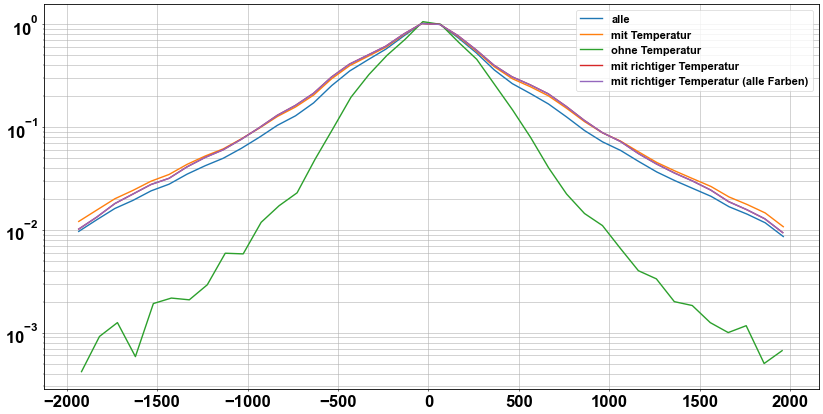

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins1[:-1]+bins1[1:])/2, n1/n1[20], label='alle')
ax.plot((bins2[:-1]+bins2[1:])/2, n2/n2[20], label='mit Temperatur')
ax.plot((bins3[:-1]+bins3[1:])/2, n3/n3[20], label='ohne Temperatur')
ax.plot((bins4[:-1]+bins4[1:])/2, n4/n4[20], label='mit richtiger Temperatur')
ax.plot((bins5[:-1]+bins5[1:])/2, n5/n5[20], label='mit richtiger Temperatur (alle Farben)')

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot((bins6[:-1]+bins6[1:])/2, n6/n6[20], label='5.00-6.00')
# ax.plot((bins7[:-1]+bins7[1:])/2, n7/n7[20], label='6.00-6.20')
# ax.plot((bins8[:-1]+bins8[1:])/2, n8/n8[20], label='6.20-6.30')
# ax.plot((bins9[:-1]+bins9[1:])/2, n9/n9[20], label='6.30-7.30')
# ax.plot((bins10[:-1]+bins10[1:])/2, n10/n10[20], label='7.30-7.40')
# ax.plot((bins11[:-1]+bins11[1:])/2, n11/n11[20], label='7.40-7.55')
# ax.plot((bins12[:-1]+bins12[1:])/2, n12/n12[20], label='7.55-8.00')

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# ax.set_title('kleines Farb-Interval')
# fig.set_dpi(50)
# plt.show()

# print('wieder 6.0 bis 7.5')

In [18]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot((bins13[:-1]+bins13[1:])/2, n13/n13[20], label='5.00-6.00')
# ax.plot((bins14[:-1]+bins14[1:])/2, n14/n14[20], label='6.00-6.20')
# ax.plot((bins15[:-1]+bins15[1:])/2, n15/n15[20], label='6.20-6.30')
# ax.plot((bins16[:-1]+bins16[1:])/2, n16/n16[20], label='6.30-7.30')
# ax.plot((bins17[:-1]+bins17[1:])/2, n17/n17[20], label='7.30-7.40')
# ax.plot((bins18[:-1]+bins18[1:])/2, n18/n18[20], label='7.40-7.55')
# ax.plot((bins19[:-1]+bins19[1:])/2, n19/n19[20], label='7.55-8.00')

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# ax.set_title('großes Farb-Interval')
# fig.set_dpi(50)
# plt.show()

# print('6.0 bis 8.0')

In [19]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot((bins20[:-1]+bins20[1:])/2, n20/n20[20], label='kleiner Faarbcut')
# ax.plot((bins21[:-1]+bins21[1:])/2, n21/n21[20], label='großer Farbcut')
# ax.plot((bins22[:-1]+bins22[1:])/2, n22/n22[20], label='sehr kleiner Farbcut')
# ax.plot((bins26[:-1]+bins26[1:])/2, n26/n26[20], label='spezieller Farbcut')

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# fig.set_dpi(50)
# plt.show()

In [20]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))
# ax.plot((bins20[:-1]+bins20[1:])/2, n20/n20[20], label='kleiner Faarbcut')
# ax.plot((bins21[:-1]+bins21[1:])/2, n21/n21[20], label='großer Farbcut')
# ax.plot((bins22[:-1]+bins22[1:])/2, n22/n22[20], label='sehr kleiner Farbcut')

# ax.plot((bins26[:-1]+bins26[1:])/2, n26/n26[20], label='spezieller Farbcut')
# ax.plot((bins27[:-1]+bins27[1:])/2, n27/n27[20], label='spezieller Farbcut rechts')
# ax.plot((bins28[:-1]+bins28[1:])/2, n28/n28[20], label='spezieller Farbcut links')
# ax.plot((bins29[:-1]+bins29[1:])/2, n29/n29[20], label='spezieller Farbcut oben')
# ax.plot((bins30[:-1]+bins30[1:])/2, n30/n30[20], label='spezieller Farbcut unten')

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# fig.set_dpi(50)
# plt.show()

In [21]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# ax.plot((bins26[:-1]+bins26[1:])/2, n26/n26[20], label='spezieller Farbcut')
# ax.plot((bins31[:-1]+bins31[1:])/2, n31/n31[20], label='absolut magnitude cut')
# ax.plot((bins32[:-1]+bins32[1:])/2, n32/n32[20], label='absolut magnitude cut')

# ax.set_yscale('log')
# plt.grid(which='both')
# plt.legend(fontsize='16')
# fig.set_dpi(50)
# plt.show()

226639
222370


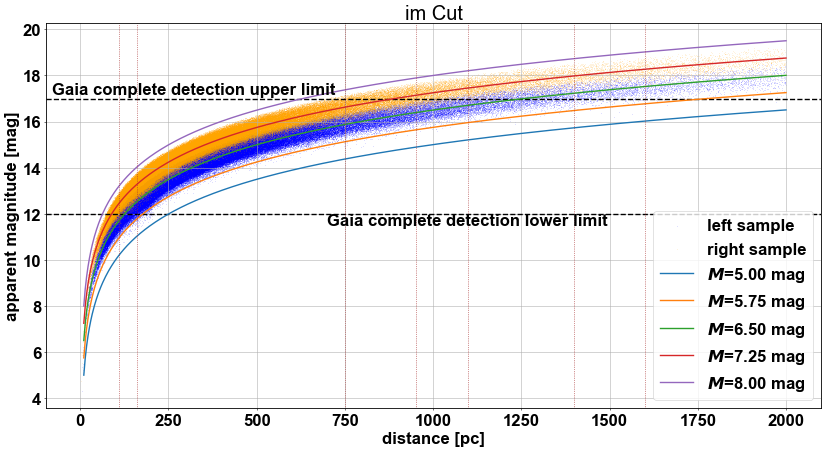

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]

ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
cut = r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)
sampleleft = (absolute_magnitude2>=left) & (absolute_magnitude2<=middle)
sampleright = (absolute_magnitude2>=middle) & (absolute_magnitude2<=right)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleleft]), apparent_magnitude2[cut&sampleleft], marker='.', c='blue', s=0.1, label='left sample', alpha=0.5)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleright]), apparent_magnitude2[cut&sampleright], marker='.', c='orange', s=0.1, label='right sample', alpha=0.5)
print(len(np.abs(dist_pc2[cut&sampleright])))
print(len(np.abs(dist_pc2[cut&sampleleft])))
z = np.linspace(0, 2000, 100)
Ms = np.linspace(5.0, 8.0, 5) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2f} mag".format(M))
plt.text(-80, 17.2, "Gaia complete detection upper limit")
plt.text(700, 11.5, "Gaia complete detection lower limit")
ax[0].grid()
ax[0].legend(loc='lower right')
ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
ax[0].set_title('im Cut')

ax[0].axvline(x=160, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=110, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=750, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=950, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=1100, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=1400, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=1600, color='brown', linestyle=':', linewidth=1)

plt.savefig('../Plots/absmag_dist.png')
fig.set_dpi(50)
plt.show()

# fig, ax = plt.subplots(3, 1, figsize=(20, 30))

# ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
# cut = r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)
# sampleleft = (absolute_magnitude2>=left) & (absolute_magnitude2<=middle)
# sampleright = (absolute_magnitude2>=middle) & (absolute_magnitude2<=right)
# scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleleft]), apparent_magnitude2[cut&sampleleft], marker='.', c='blue', s=0.1, label='Gaia DR3 data left sample', alpha=0.2)
# scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleright]), apparent_magnitude2[cut&sampleright], marker='.', c='orange', s=0.1, label='Gaia DR3 data right sample', alpha=0.2)
# z = np.linspace(0, 2000, 100)
# # ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# # ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# # ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# # ax[0].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[0].grid()
# ax[0].legend(loc='lower right')
# ax[0].set_ylabel('apparent magnitude [mag]')
# ax[0].set_xlabel('distance [pc]')
# ax[0].set_title('im Cut')

# ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
# nichtcut = (r&(teff2>=3900)&(teff2<=5300))&(~(absolute_magnitude2>=o1)|~(absolute_magnitude2<=m4)|~(absolute_magnitude2<=right)|~(absolute_magnitude2>=left))
# scatter2 = ax[1].scatter(np.abs(dist_pc2[nichtcut]), apparent_magnitude2[nichtcut], marker='.', s=0.5, label='Gaia DR3 data', c=teff2[nichtcut], cmap='viridis')
# z = np.linspace(0, 2000, 100)
# # ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# # ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# # ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# # ax[1].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Effective temperature [K]')

# ax[1].grid()
# ax[1].legend(loc='lower right')
# ax[1].set_ylabel('apparent magnitude [mag]')
# ax[1].set_xlabel('distance [pc]')
# ax[1].set_title('im Zylinder nicht im cut richtige Temperatur')


# ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)
# nichtcut_ = (r&np.isnan(teff2))&(~(absolute_magnitude2>=o1)|~(absolute_magnitude2<=m4)|~(absolute_magnitude2<=right)|~(absolute_magnitude2>=left))
# scatter3 = ax[2].scatter(np.abs(dist_pc2[nichtcut_]), apparent_magnitude2[nichtcut_], marker='.', s=0.5, label='Gaia DR3 data', c='black')
# z = np.linspace(0, 2000, 100)
# # ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# # ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# # ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# # ax[2].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[2].grid()
# ax[2].legend(loc='lower right')
# ax[2].set_ylabel('apparent magnitude [mag]')
# ax[2].set_xlabel('distance [pc]')
# ax[2].set_title('im Zylinder nicht im cut keine Temperatur')

# plt.savefig('../Plots/absmag_dist.png')
# fig.set_dpi(50)
# plt.show()

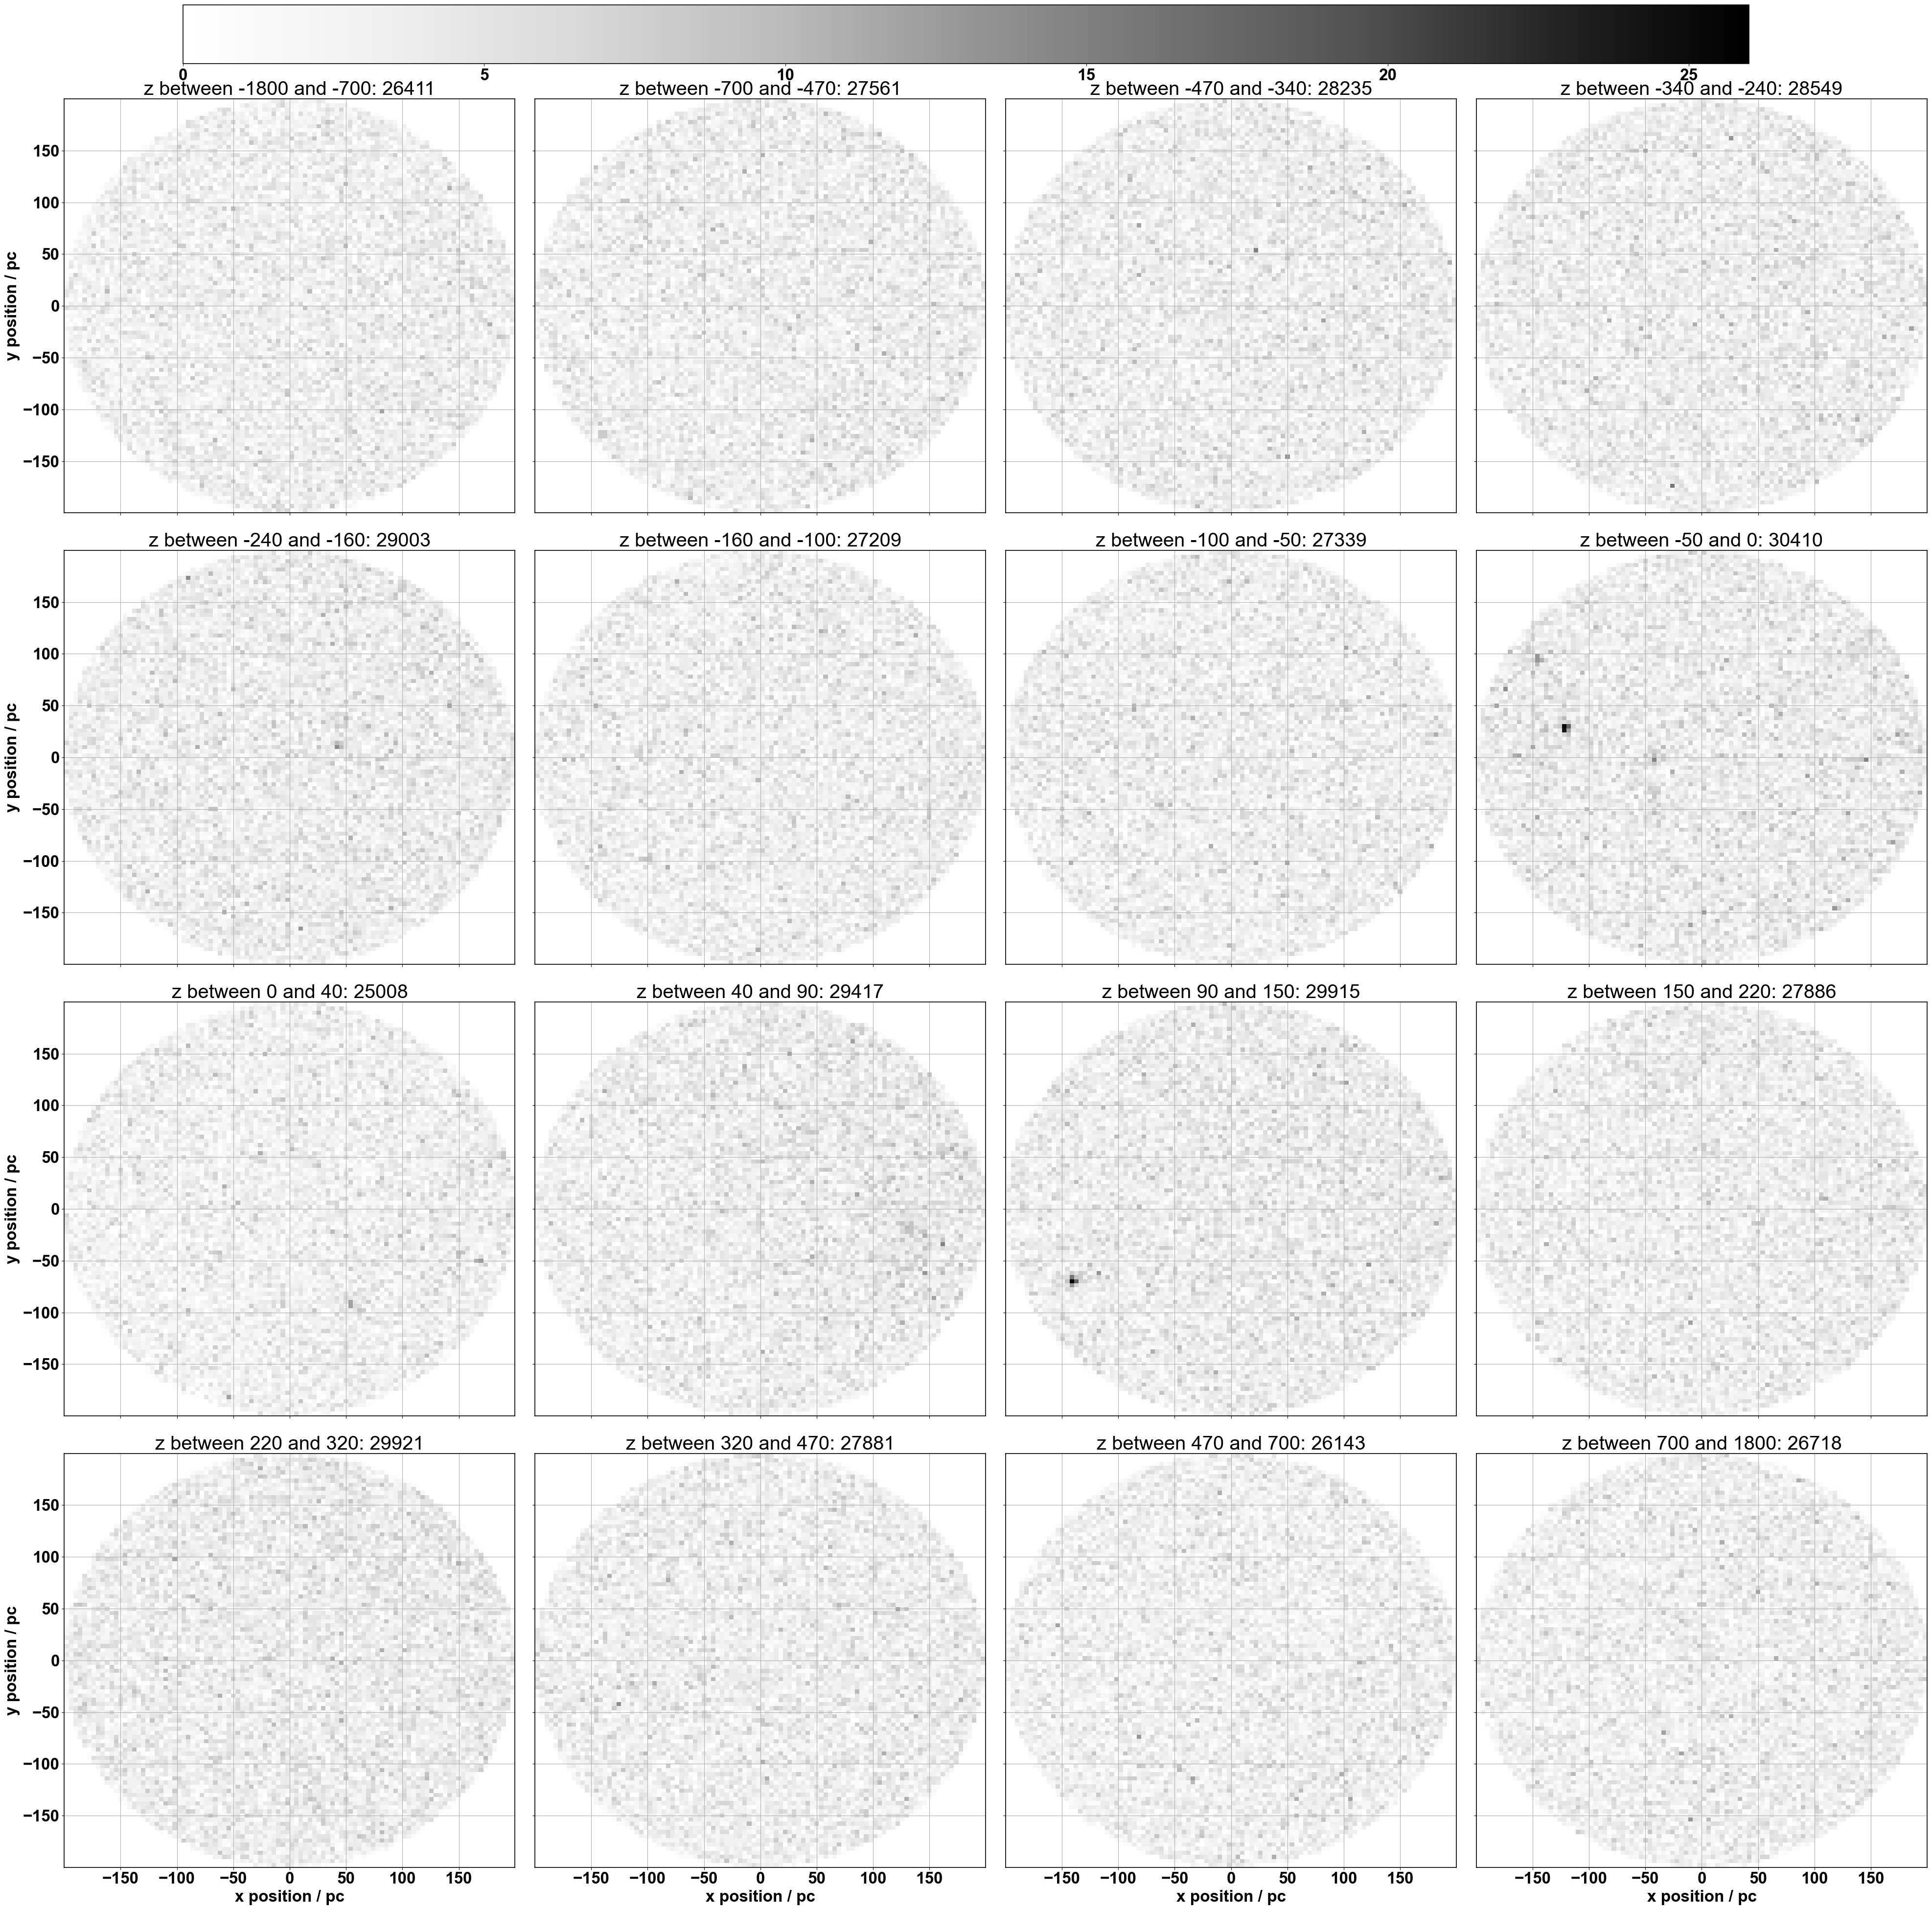

'scan(90, 150, n=9)'

In [23]:
def scan(scan_min, scan_max, n, intervals=None):
    if intervals is None:
        intervals = np.linspace(scan_min, scan_max, n+1)
    else: 
        n= len(intervals) - 1
    length = int(np.ceil(np.sqrt(n)))
    fig, ax = plt.subplots(length, length, figsize=(10*length, 10*length), sharex=True, sharey=True)
    ax = ax.flatten()

    # Initialize min and max counts
    all_counts = []

    # First pass to determine the overall min and max counts for normalization
    for i in range(n):
        mask = (z_pc2[cut] > intervals[i]) & (z_pc2[cut] <= intervals[i+1])
        data = tab2[cut][mask]

        x = r_from_plx(data["parallax"]) * np.cos(data["b"] * deg2rad) * np.cos(data["l"] * deg2rad)
        y = r_from_plx(data["parallax"]) * np.cos(data["b"] * deg2rad) * np.sin(data["l"] * deg2rad)

        if scan_min < 0 and scan_max <= 0:
            i = n - i - 1

        # Calculate histogram counts without plotting
        counts, _, _ = np.histogram2d(x, y, bins=100)
        all_counts.append(counts)

    # Determine the global min and max for color scale normalization
    global_min = np.min([np.min(count) for count in all_counts])
    global_max = np.max([np.max(count) for count in all_counts])

    # Second pass to create plots with normalized color scale
    for i in range(n):
        mask = (z_pc2[cut] > intervals[i]) & (z_pc2[cut] <= intervals[i+1])
        data = tab2[cut][mask]

        x = r_from_plx(data["parallax"]) * np.cos(data["b"] * deg2rad) * np.cos(data["l"]*deg2rad)
        y = r_from_plx(data["parallax"]) * np.cos(data["b"] * deg2rad) * np.sin(data["l"]*deg2rad)

        if scan_min < 0 and scan_max <= 0:
            i = n - i - 1

        # Create a 2D histogram with the global color scale
        h = ax[i].hist2d(x, y, bins=100, cmap='Greys', vmin=global_min, vmax=global_max)

        ax[i].set_title('z between {:.0f} and {:.0f}: {}'.format(intervals[i], intervals[i+1], len(data)))

        if i % length == 0:
            ax[i].set_ylabel('y position / pc')
        if i >= n - length:
            ax[i].set_xlabel('x position / pc')
        ax[i].grid(True)

    # Adjust the layout to prevent overlap and place the colorbar properly
    fig.tight_layout(rect=[0, 0, 1, 0.95])  # Adjusts the entire figure to give room for the colorbar
    cbar_ax = fig.add_axes([0.1, 0.95, 0.8, 0.03])  # Create a new axis for the colorbar
    fig.colorbar(h[3], cax=cbar_ax, orientation='horizontal')  # Add colorbar to the new axis
    plt.savefig('../Plots/scan.png')
    plt.show()

scan(-1800, 1800, n=25, intervals=[-1800, -700, -470, -340, -240, -160, -100, -50, 0, 40, 90, 150, 220, 320, 470, 700, 1800])
'scan(90, 150, n=9)'

In [24]:
# fig, ax = plt.subplots(3, 1, figsize=(20, 30))
# ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)

# scatter = ax[0].scatter(np.abs(dist_pc2[r&br]), apparent_magnitude2[r&br], marker='.', s=0.5, label='Gaia DR3 data')
# z = np.linspace(0, 2000, 100)
# ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[0].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[0].grid()
# ax[0].legend(loc='lower right')

# ax[0].set_ylabel('apparent magnitude [mag]')
# ax[0].set_xlabel('distance [pc]')
# ax[0].set_title('im colour cut')

# ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
# scatter2 = ax[1].scatter(np.abs(dist_pc2[r&~br&(teff2>=4000)&(teff2<=5000)]), apparent_magnitude2[r&~br&(teff2>=4000)&(teff2<=5000)], marker='.', s=0.5, label='Gaia DR3 data', c=teff2[r&~br&(teff2>=4000)&(teff2<=5000)], cmap='viridis')
# z = np.linspace(0, 2000, 100)
# ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[1].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[1].grid()
# ax[1].legend(loc='lower right')

# ax[1].set_ylabel('apparent magnitude [mag]')
# ax[1].set_xlabel('distance [pc]')
# ax[1].set_title('im Zylinder nicht im colour cut richtige Temperatur')
# colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Effective temperature [K]')

# ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)

# scatter3 = ax[2].scatter(np.abs(dist_pc2[r&~br&np.isnan(teff2)]), apparent_magnitude2[r&~br&np.isnan(teff2)], marker='.', s=0.5, label='Gaia DR3 data')
# z = np.linspace(0, 2000, 100)
# ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[2].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[2].grid()
# ax[2].legend(loc='lower right')

# ax[2].set_ylabel('apparent magnitude [mag]')
# ax[2].set_xlabel('distance [pc]')
# ax[2].set_title('im Zylinder nicht im colour cut keine Temperatur')

# fig.set_dpi(50)
# plt.show()

In [25]:
# fig, ax = plt.subplots(3, 1, figsize=(20, 30))
# ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)

# scatter = ax[0].scatter(np.abs(dist_pc2[r&br2]), apparent_magnitude2[r&br2], marker='.', s=0.5, label='Gaia DR3 data')
# z = np.linspace(0, 2000, 100)
# ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[0].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[0].grid()
# ax[0].legend(loc='lower right')

# ax[0].set_ylabel('apparent magnitude [mag]')
# ax[0].set_xlabel('distance [pc]')
# ax[0].set_title('im colour cut')

# ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
# scatter2 = ax[1].scatter(np.abs(dist_pc2[r&~br2&(teff2>=3900)&(teff2<=6000)]), apparent_magnitude2[r&~br2&(teff2>=3900)&(teff2<=6000)], marker='.', s=0.5, label='Gaia DR3 data', c=teff2[r&~br2&(teff2>=3900)&(teff2<=6000)], cmap='viridis')
# z = np.linspace(0, 2000, 100)
# ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[1].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[1].grid()
# ax[1].legend(loc='lower right')

# ax[1].set_ylabel('apparent magnitude [mag]')
# ax[1].set_xlabel('distance [pc]')
# ax[1].set_title('im Zylinder nicht im colour cut richtige Temperatur')
# colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Effective temperature [K]')

# ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
# ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)

# scatter3 = ax[2].scatter(np.abs(dist_pc2[r&~br2&np.isnan(teff2)]), apparent_magnitude2[r&~br2&np.isnan(teff2)], marker='.', s=0.5, label='Gaia DR3 data')
# z = np.linspace(0, 2000, 100)
# ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
# ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
# ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
# ax[2].plot(z, M_d_to_m(7.5, z), color='black', linestyle='--', linewidth=2, label=' final selection')

# ax[2].grid()
# ax[2].legend(loc='lower right')

# ax[2].set_ylabel('apparent magnitude [mag]')
# ax[2].set_xlabel('distance [pc]')
# ax[2].set_title('im Zylinder nicht im colour cut keine Temperatur')

# fig.set_dpi(50)
# plt.show()